# BSM 方程与二叉树模型

## 软件包导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from scipy.stats import alpha

import derivlab as dl

## BSM 价格 vs 波动率


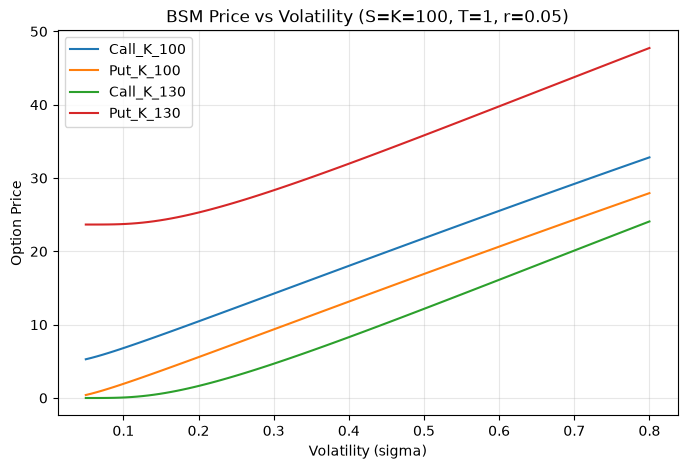

In [5]:
sigmas = np.linspace(0.05, 0.8, 100)
S, K, T, r = 100, 100, 1.0, 0.05

call_prices_k_100 = [dl.bsm_price(S, K ,T, r, sig, "call") for sig in sigmas]
put_prices_k_100 = [dl.bsm_price(S, K ,T, r, sig, "put") for sig in sigmas]

call_prices_k_130 = [dl.bsm_price(S, 130 ,T, r, sig, "call") for sig in sigmas]
put_prices_k_130 = [dl.bsm_price(S, 130 ,T, r, sig, "put") for sig in sigmas]

plt.figure(figsize=(8, 5))
plt.plot(sigmas, call_prices_k_100, label="Call_K_100")
plt.plot(sigmas, put_prices_k_100, label="Put_K_100")
plt.plot(sigmas, call_prices_k_130, label="Call_K_130")
plt.plot(sigmas, put_prices_k_130, label="Put_K_130")
plt.xlabel("Volatility (sigma)")
plt.ylabel("Option Price")
plt.title("BSM Price vs Volatility (S=K=100, T=1, r=0.05)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

有意思的是，在 $K = 100$ 的时候，两根直线近似是线性的直线。把 $K$ 远离 $100$ 之后，我们才看到曲线的变化。低波动率时，价格几乎为零，中段陡峭怕生，这正是虚值期权对波动率最敏感、曲率最明显的地方。


## 二叉树收敛到 BSM


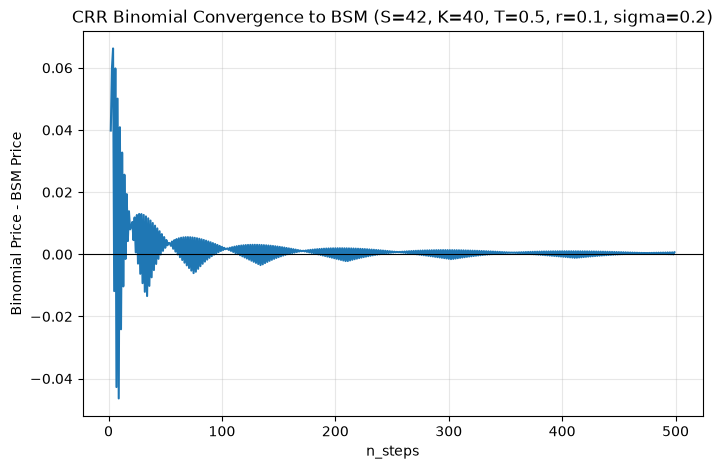

In [12]:
n_steps_range = np.arange(2, 500)
S, K, T, r, sigma = 42, 40, 0.5, 0.10, 0.20 # 教材用例

bsm = dl.bsm_price(S, K, T, r, sigma, "call")
errors = [
    dl.crr_binomial_price(S, K, T, r, sigma, n_steps=int(n), option_type="call") - bsm
    for n in n_steps_range
] # 计算两个模型之间的偏差

plt.figure(figsize=(8,5))
plt.plot(n_steps_range, errors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("n_steps")
plt.ylabel("Binomial Price - BSM Price")
plt.title(f"CRR Binomial Convergence to BSM (S={S}, K={K}, T={T}, r={r}, sigma={sigma})")
plt.grid(alpha=0.3)
plt.show()

这个图我们可以看出以下几个特点：

1. 整体呈现震荡的图案：误差在 $0$ 附近上下震动，幅度随步数增大而收敛。
2. 震荡并不是以 $0$ 为均值震荡的。可以明显看出，$0$ 上方的数值点明显更多。单个震荡的“波节”，其均值似乎是偏正的。

下面来验证这个观察与猜想。


In [8]:
# TODO: 二叉树误差符号偏差(positive_frac)随 S 呈现非单调、中间凸起两头压平的形状,背后应该是离散化网格对齐效应,和 σ/T/n 都耦合在一起，值得后续深入分析(可能涉及 Edgeworth 展开 / 离散二项分布逼近对数正态分布的误差项)。留待后面专门研究。

ITM positive_frac: 0.6887550200803213
ATM positive_frac: 0.5


## 美式 vs 欧式看跌期权的早行权溢价


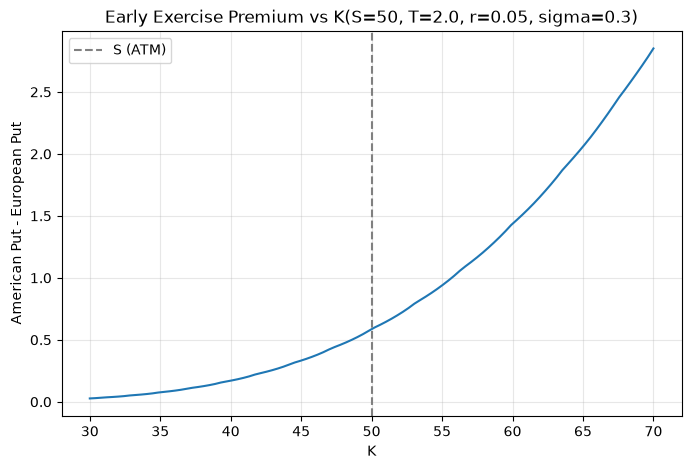

In [14]:
Ks = np.linspace(30,70,100)
S, T, r, sigma = 50, 2.0, 0.05, 0.3
n_steps = 200

american_puts = [
    dl.crr_binomial_price(S, K, T, r, sigma, n_steps, option_type="put", exercise="american")
    for K in Ks
]
european_puts = [
    dl.crr_binomial_price(S, K, T, r, sigma, n_steps, option_type="put", exercise="european")
    for K in Ks
]
premium = np.array(american_puts) - np.array(european_puts)

plt.figure(figsize=(8, 5))
plt.plot(Ks, premium)
plt.axvline(S, color="gray", linestyle="--", label="S (ATM)")
plt.xlabel("K")
plt.ylabel("American Put - European Put")
plt.title(f"Early Exercise Premium vs K(S={S}, T={T}, r={r}, sigma={sigma})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

预期看到:K 远小于 S 时，溢价接近 $0$；K 越大溢价越明显——因为深度实值 put 提前行权拿到手里的现金能生息,时间越长，利率越高,这个提前行权的价值就越大。这也是全书里"美式 put 提前行权"这个经典结论的直接可视化。